In [ ]:
#Install dependencies
!pip install rasterio xarray rioxarray matplotlib numpy pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:00


In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import xarray as xr
import rioxarray

In [8]:
#Define data directory and list files
data_dir = '/content/drive/MyDrive/GEE_LST_Exports'

files = sorted(os.listdir(data_dir))
print('Files in GEE_LST_Exports:')
for f in files:
    print(f' {f}')

Files in GEE_LST_Exports:
 LST_Anomaly_2023.tif
 LST_Kozan_Summer_2020_2025.tif
 LST_Summer_Mean_2020_2025.tif
 LST_Winter_Mean_2020_2025.tif
 Landsat_LST_Kozan_Summer_2020_2025.tif
 Landsat_LST_Summer_2020_2025.tif
 Landsat_LST_Winter_2020_2025.tif
 MODIS_LST_Monthly_Time_Series.csv
 MODIS_LST_Monthly_Timeseries.csv
 landsat_overview.png
 lst_overview.png
 lst_timeseries_interpolation.png
 modis_vs_landsat.png


In [9]:
#Define file paths

# MODIS LST files (1km resolution)
summer_path  = f'{data_dir}/LST_Summer_Mean_2020_2025.tif'
winter_path  = f'{data_dir}/LST_Winter_Mean_2020_2025.tif'
anomaly_path = f'{data_dir}/LST_Anomaly_2023.tif'
kozan_path   = f'{data_dir}/LST_Kozan_Summer_2020_2025.tif'

# Landsat LST files (30m resolution)
ls_summer_path = f'{data_dir}/Landsat_LST_Summer_2020_2025.tif'
ls_winter_path = f'{data_dir}/Landsat_LST_Winter_2020_2025.tif'
ls_kozan_path  = f'{data_dir}/Landsat_LST_Kozan_Summer_2020_2025.tif'

print('File paths defined.')

File paths defined.


In [10]:
#Read GeoTIFF files and print statistics
def read_tif(path):
    """Read a GeoTIFF file, replace NoData with NaN, print basic stats."""
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        profile = src.profile
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        print(f'File : {os.path.basename(path)}')
        print(f'  Size : {src.width} x {src.height} px')
        print(f'  CRS  : {src.crs}')
        print(f'  Min  : {np.nanmin(data):.2f} °C')
        print(f'  Max  : {np.nanmax(data):.2f} °C')
        print(f'  Mean : {np.nanmean(data):.2f} °C')
        print()
    return data, profile

# Read all files
summer_data,    summer_profile    = read_tif(summer_path)
winter_data,    winter_profile    = read_tif(winter_path)
anomaly_data,   anomaly_profile   = read_tif(anomaly_path)
kozan_data,     kozan_profile     = read_tif(kozan_path)
ls_summer_data, ls_summer_profile = read_tif(ls_summer_path)
ls_winter_data, ls_winter_profile = read_tif(ls_winter_path)
ls_kozan_data,  ls_kozan_profile  = read_tif(ls_kozan_path)

File : LST_Summer_Mean_2020_2025.tif
  Size : 216 x 288 px
  CRS  : EPSG:4326
  Min  : 17.50 °C
  Max  : 48.26 °C
  Mean : 35.96 °C

File : LST_Winter_Mean_2020_2025.tif
  Size : 216 x 288 px
  CRS  : EPSG:4326
  Min  : -9.96 °C
  Max  : 24.23 °C
  Mean : 10.91 °C

File : LST_Anomaly_2023.tif
  Size : 216 x 288 px
  CRS  : EPSG:4326
  Min  : -20.11 °C
  Max  : 15.42 °C
  Mean : -0.19 °C

File : LST_Kozan_Summer_2020_2025.tif
  Size : 91 x 65 px
  CRS  : EPSG:4326
  Min  : 27.51 °C
  Max  : 43.51 °C
  Mean : 35.66 °C

File : Landsat_LST_Summer_2020_2025.tif
  Size : 2969 x 5940 px
  CRS  : EPSG:4326
  Min  : 22.92 °C
  Max  : 60.62 °C
  Mean : 40.65 °C

File : Landsat_LST_Winter_2020_2025.tif
  Size : 2969 x 5940 px
  CRS  : EPSG:4326
  Min  : -6.51 °C
  Max  : 31.45 °C
  Mean : 14.47 °C

File : Landsat_LST_Kozan_Summer_2020_2025.tif
  Size : 2969 x 5940 px
  CRS  : EPSG:4326
  Min  : 28.69 °C
  Max  : 51.32 °C
  Mean : 39.57 °C



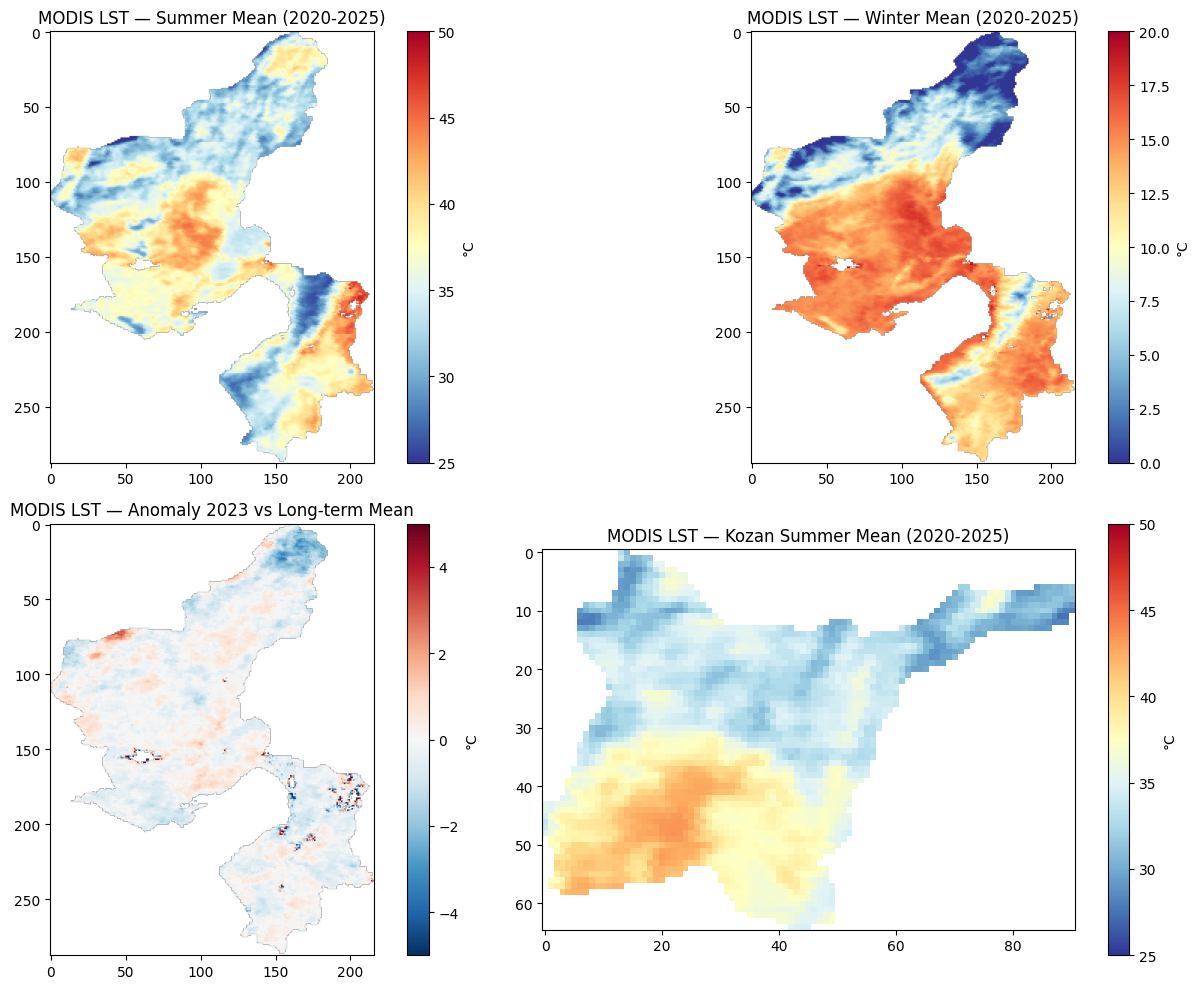

MODIS overview saved.


In [11]:
#Visualization MODIS LST layers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im1 = axes[0, 0].imshow(summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[0, 0].set_title('MODIS LST — Summer Mean (2020-2025)')
plt.colorbar(im1, ax=axes[0, 0], label='°C')

im2 = axes[0, 1].imshow(winter_data, cmap='RdYlBu_r', vmin=0, vmax=20)
axes[0, 1].set_title('MODIS LST — Winter Mean (2020-2025)')
plt.colorbar(im2, ax=axes[0, 1], label='°C')

im3 = axes[1, 0].imshow(anomaly_data, cmap='RdBu_r', vmin=-5, vmax=5)
axes[1, 0].set_title('MODIS LST — Anomaly 2023 vs Long-term Mean')
plt.colorbar(im3, ax=axes[1, 0], label='°C')

im4 = axes[1, 1].imshow(kozan_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[1, 1].set_title('MODIS LST — Kozan Summer Mean (2020-2025)')
plt.colorbar(im4, ax=axes[1, 1], label='°C')

plt.tight_layout()
plt.savefig(f'{data_dir}/modis_lst_overview.png', dpi=150)
plt.show()
print('MODIS overview saved.')

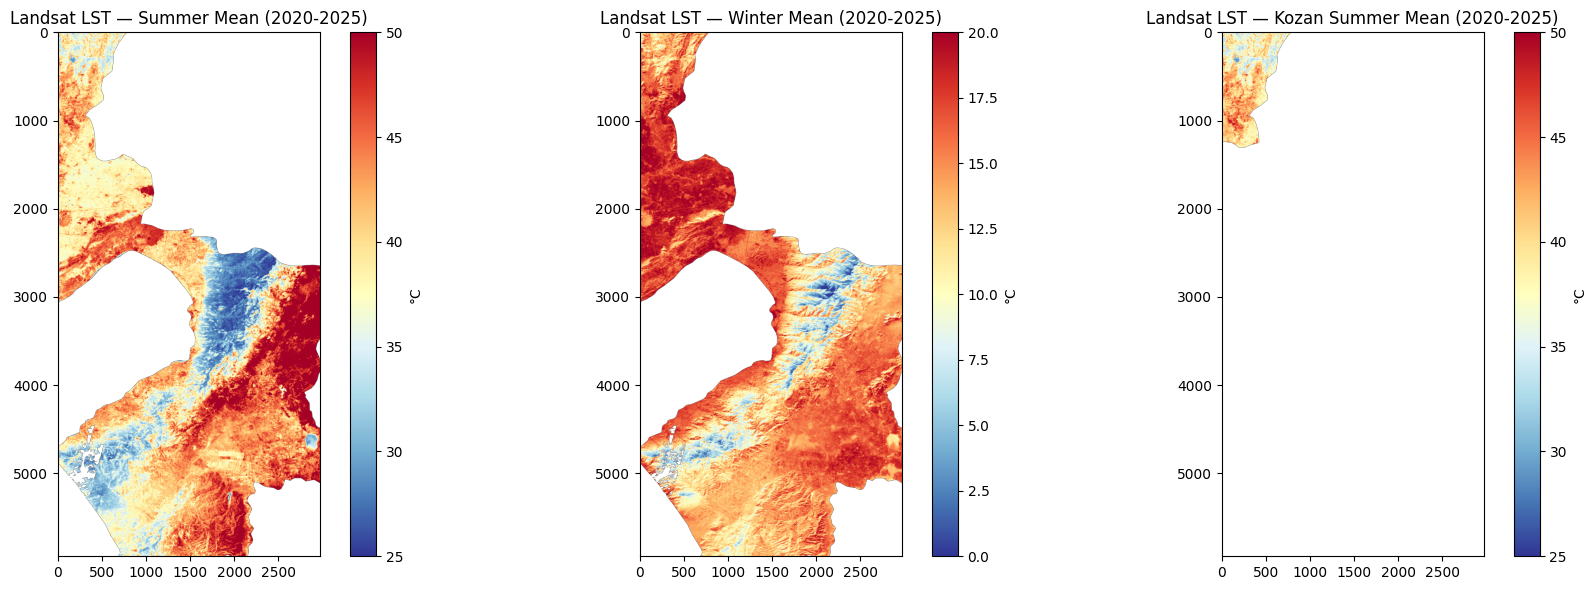

Landsat overview saved.


In [20]:
#Visualization Landsat layers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im5 = axes[0].imshow(ls_summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[0].set_title('Landsat LST — Summer Mean (2020-2025)')
plt.colorbar(im5, ax=axes[0], label='°C')

im6 = axes[1].imshow(ls_winter_data, cmap='RdYlBu_r', vmin=0, vmax=20)
axes[1].set_title('Landsat LST — Winter Mean (2020-2025)')
plt.colorbar(im6, ax=axes[1], label='°C')

im7 = axes[2].imshow(ls_kozan_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[2].set_title('Landsat LST — Kozan Summer Mean (2020-2025)')
plt.colorbar(im7, ax=axes[2], label='°C')

plt.tight_layout()
plt.savefig(f'{data_dir}/landsat_lst_overview.png', dpi=150)
plt.show()
print('Landsat overview saved.')

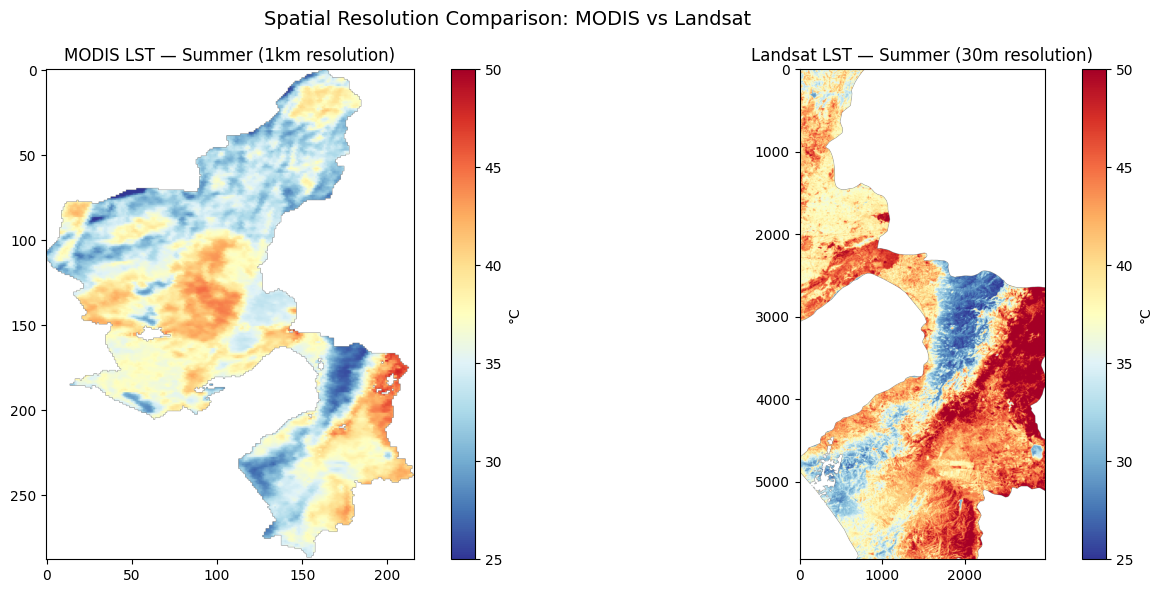

Resolution comparison saved.


In [14]:
#Resolution comparison : MODIS vs Landsat
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MODIS Summer
im1 = axes[0].imshow(summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[0].set_title('MODIS LST — Summer (1km resolution)')
plt.colorbar(im1, ax=axes[0], label='°C')

# Landsat Summer
im2 = axes[1].imshow(ls_summer_data, cmap='RdYlBu_r', vmin=25, vmax=50)
axes[1].set_title('Landsat LST — Summer (30m resolution)')
plt.colorbar(im2, ax=axes[1], label='°C')

plt.suptitle('Spatial Resolution Comparison: MODIS vs Landsat', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEE_LST_Exports/modis_vs_landsat.png', dpi=150)
plt.show()
print('Resolution comparison saved.')

In [15]:
# Load and inspect monthly time series CSV
csv_path = f'{data_dir}/MODIS_LST_Monthly_Timeseries.csv'
df = pd.read_csv(csv_path, parse_dates=['date'])
df = df[['date', 'year', 'month', 'LST_mean']].sort_values('date').reset_index(drop=True)

print(f'Rows     : {len(df)}')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
print(f'LST range : {df["LST_mean"].min():.2f} — {df["LST_mean"].max():.2f} °C')
print()
print(df.head(12))

Rows     : 60
Date range: 2020-01-01 00:00:00 → 2024-12-01 00:00:00
LST range : 4.01 — 37.70 °C

         date    year  month   LST_mean
0  2020-01-01  2020.0    1.0   6.534671
1  2020-02-01  2020.0    2.0   9.596978
2  2020-03-01  2020.0    3.0  16.787859
3  2020-04-01  2020.0    4.0  24.965969
4  2020-05-01  2020.0    5.0  31.658172
5  2020-06-01  2020.0    6.0  33.726730
6  2020-07-01  2020.0    7.0  37.324542
7  2020-08-01  2020.0    8.0  36.958457
8  2020-09-01  2020.0    9.0  35.806491
9  2020-10-01  2020.0   10.0  29.733330
10 2020-11-01  2020.0   11.0  18.022000
11 2020-12-01  2020.0   12.0  12.407966


In [16]:
#Missing value check and interpolation

# Build a complete monthly date index (2020-01 to 2024-12)
all_dates = pd.date_range(start='2020-01-01', end='2024-12-01', freq='MS')
df_full = pd.DataFrame({'date': all_dates})
df_full = df_full.merge(df[['date', 'LST_mean']], on='date', how='left')

missing_count = df_full['LST_mean'].isna().sum()
print(f'Missing months: {missing_count}')

if missing_count == 0:
    print('No missing values — interpolation not required.')
    print('Linear and cubic columns are added for consistency.')

# Apply interpolation regardless (documents pipeline completeness)
df_full['LST_linear'] = df_full['LST_mean'].interpolate(method='linear')
df_full['LST_cubic']  = df_full['LST_mean'].interpolate(method='cubic')

print(df_full.head(12))

Missing months: 0
No missing values — interpolation not required.
Linear and cubic columns are added for consistency.
         date   LST_mean  LST_linear  LST_cubic
0  2020-01-01   6.534671    6.534671   6.534671
1  2020-02-01   9.596978    9.596978   9.596978
2  2020-03-01  16.787859   16.787859  16.787859
3  2020-04-01  24.965969   24.965969  24.965969
4  2020-05-01  31.658172   31.658172  31.658172
5  2020-06-01  33.726730   33.726730  33.726730
6  2020-07-01  37.324542   37.324542  37.324542
7  2020-08-01  36.958457   36.958457  36.958457
8  2020-09-01  35.806491   35.806491  35.806491
9  2020-10-01  29.733330   29.733330  29.733330
10 2020-11-01  18.022000   18.022000  18.022000
11 2020-12-01  12.407966   12.407966  12.407966


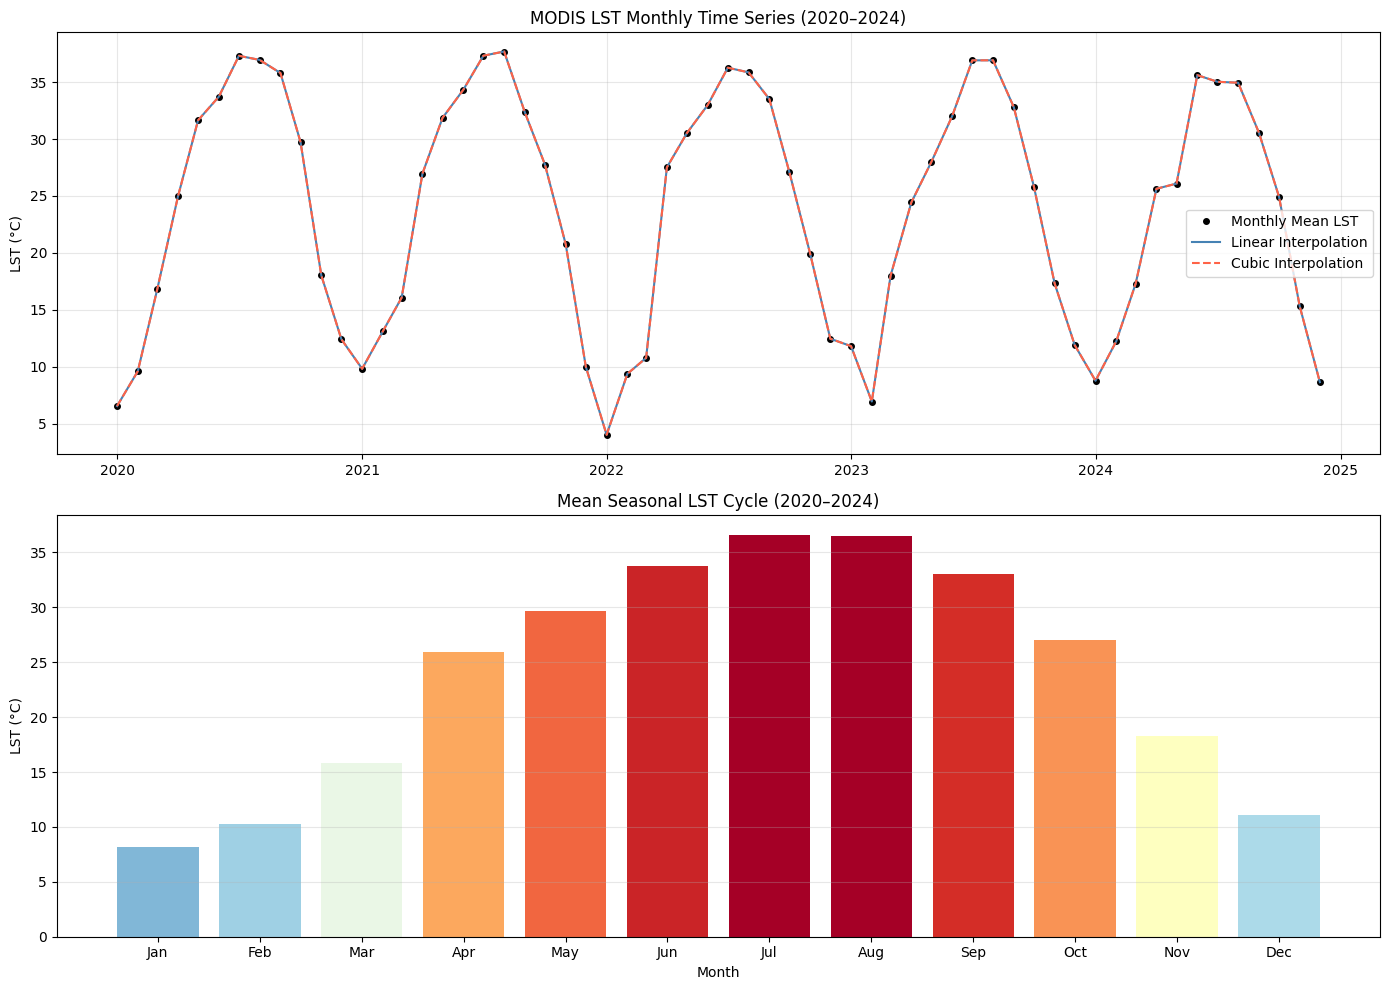

Time series visualization saved.


In [17]:
# Time series visualization

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Upper panel: raw data and interpolation curves
axes[0].plot(df_full['date'], df_full['LST_mean'],
             'o', color='black', label='Monthly Mean LST', markersize=4)
axes[0].plot(df_full['date'], df_full['LST_linear'],
             '-', color='steelblue', label='Linear Interpolation', linewidth=1.5)
axes[0].plot(df_full['date'], df_full['LST_cubic'],
             '--', color='tomato', label='Cubic Interpolation', linewidth=1.5)
axes[0].set_title('MODIS LST Monthly Time Series (2020–2024)')
axes[0].set_ylabel('LST (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lower panel: mean seasonal cycle
monthly_mean = df_full.groupby(df_full['date'].dt.month)['LST_mean'].mean()
colors = plt.cm.RdYlBu_r(monthly_mean.values / monthly_mean.max())
axes[1].bar(monthly_mean.index, monthly_mean.values, color=colors)
axes[1].set_title('Mean Seasonal LST Cycle (2020–2024)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('LST (°C)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May',
                          'Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{data_dir}/lst_timeseries_interpolation.png', dpi=150)
plt.show()
print('Time series visualization saved.')

In [18]:
#xarray: load summer LST as labeled array

# Load MODIS summer GeoTIFF as xarray DataArray for downstream use
da_summer = rioxarray.open_rasterio(summer_path).squeeze()
da_summer = da_summer.where(da_summer != da_summer.attrs.get('_FillValue', -9999))
da_summer.name = 'LST_Summer'

print(da_summer)
print(f'\nMean LST (xarray): {float(da_summer.mean()):.2f} °C')

<xarray.DataArray 'LST_Summer' (y: 288, x: 216)> Size: 498kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 2kB 38.39 38.38 38.37 38.36 ... 35.83 35.82 35.81
  * x            (x) float64 2kB 34.78 34.79 34.8 34.81 ... 36.69 36.7 36.71
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      LST_Summer

Mean LST (xarray): 35.96 °C
